<a href="https://colab.research.google.com/github/Kusanis/Crypto-eKAN/blob/main/KAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 13.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
BTC = yf.Ticker('XRP-USD')
data = BTC.history(start='2010-03-01',end='2025-03-01')

In [ ]:
Scaler = MinMaxScaler()
data[['Close']] = Scaler.fit_transform(data[['Close']])
data['prev1'] = data['Close'].shift(1)
data['prev2'] = data['Close'].shift(2)
data['prev3'] = data['Close'].shift(3)
data['prev4'] = data['Close'].shift(4)
# Calculate Simple Moving Average (SMA)
data['SMA'] = data['prev1'].rolling(window=7).mean()

# Calculate Exponential Moving Average (EMA)
data['EMA'] = data['prev1'].ewm(span=30, adjust=False).mean()

# Function to calculate Relative Strength Index (RSI)
def calculate_rsi(data, window):
    delta = data.diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Calculate RSI
data['RSI'] = calculate_rsi(data['prev1'], 14)
data = data.drop(data[['Open','High','Low','Dividends','Stock Splits']],axis=1)
data = data.dropna()
data['Date'] = data.index


In [ ]:
train_df, test_df = train_test_split(data, test_size=0.3, random_state=42, shuffle = False)
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=42, shuffle = False)

In [ ]:
# Sample data (Replace these with actual data)
X_train = train_df[['prev1','prev2','prev3','prev4']]
y_train = train_df['Close']

X_test = test_df[['prev1','prev2','prev3','prev4']]
y_test = test_df['Close']

X_val = val_df[['prev1','prev2','prev3','prev4']]
y_val = val_df['Close']

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import GRU, Dense, Flatten, Dropout, LSTM
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, Ridge

X_train_LSTM = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_LSTM = X_val.values.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_LSTM = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

def bRFR(best_params):
  rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
  return rf_best

def bLR(best_params):
  if best_params["model_type"] == "ridge":
    model_best = Ridge(alpha=best_params["alpha"], random_state=42)
  else:
    model_best = Lasso(alpha=best_params["alpha"], random_state=42)
  return model_best

def bGBR(best_params):
  best_gb = GradientBoostingRegressor(
    **best_params,
    random_state=42
  )
  return best_gb

def bGRU(best_params):
  best_model = Sequential()
  best_model.add(GRU(units=best_params["n_units"], return_sequences=True, input_shape=(3, 1)))
  best_model.add(GRU(units=best_params["n_units"]))
  best_model.add(Dense(1))
  best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mean_squared_error')
  return best_model

def bLSTM(best_params):
  best_model = Sequential()
  best_model.add(LSTM(units=best_params['n_units'], return_sequences=True, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
  best_model.add(Dropout(best_params['dropout_rate']))
  best_model.add(LSTM(units=best_params['n_units']))
  best_model.add(Dropout(best_params['dropout_rate']))
  best_model.add(Dense(1))
  best_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mean_squared_error')
  return best_model

def bMLP(best_params):
  best_model = Sequential()
  best_model.add(Flatten(input_shape=(X_train.shape[1],)))
  for _ in range(best_params["n_layers"]):
      best_model.add(Dense(units=best_params["n_units"], activation='relu'))
  best_model.add(Dense(1))
  best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mean_squared_error')
  return best_model


best_params={'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None}
rfr_model = bRFR(best_params)
rfr_model.fit(X_train, y_train)
val_preds_rfr = rfr_model.predict(X_val)
test_preds_rfr = rfr_model.predict(X_test)
r2 = r2_score(y_test, test_preds_rfr)
print(r2)

best_params={'model_type': 'ridge', 'alpha': 0.0013957618281066919}
lr_model = bLR(best_params)
lr_model.fit(X_train, y_train)
val_preds_lr = lr_model.predict(X_val)
test_preds_lr = lr_model.predict(X_test)
r2 = r2_score(y_test, test_preds_lr)
print(r2)


best_params={'n_estimators': 409, 'learning_rate': 0.2687756080212663, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'subsample': 0.6983834983261011, 'max_features': 'sqrt'}
gbr_model = bGBR(best_params)
gbr_model.fit(X_train, y_train)
val_preds_gbr = gbr_model.predict(X_val)
test_preds_gbr = gbr_model.predict(X_test)
r2 = r2_score(y_test, test_preds_gbr)
print(r2)

best_params={'n_units': 90, 'learning_rate': 0.00035392099682904875, 'dropout_rate': 0.2118285720165366, 'n_batch': 83}
lstm_model = bLSTM(best_params)
lstm_model.fit(X_train_LSTM, y_train, epochs=50, batch_size=best_params["n_batch"], validation_data=(X_val_LSTM, y_val))
val_preds_lstm = lstm_model.predict(X_val_LSTM).flatten()
test_preds_lstm = lstm_model.predict(X_test_LSTM).flatten()
r2 = r2_score(y_test, test_preds_lstm)
print(r2)


best_params={'n_units': 122, 'n_epochs': 60, 'n_batch': 64, 'learning_rate': 1.1526170513193388e-05}
gru_model = bGRU(best_params)
gru_model.fit(X_train_LSTM, y_train, epochs=best_params["n_epochs"], batch_size=best_params["n_batch"], validation_data=(X_val_LSTM, y_val))
val_preds_gru = gru_model.predict(X_val_LSTM).flatten()
test_preds_gru = gru_model.predict(X_test_LSTM).flatten()
r2 = r2_score(y_test, test_preds_gru)
print(r2)

best_params={'n_layers': 3, 'n_units': 122, 'n_epochs': 42, 'n_batch': 64, 'learning_rate': 0.0002264186806791356}
mlp_model = bMLP(best_params)
mlp_model.fit(X_train, y_train, epochs=best_params["n_epochs"], batch_size=best_params["n_batch"], validation_data=(X_val, y_val))
val_preds_mlp = mlp_model.predict(X_val).flatten()
test_preds_mlp = mlp_model.predict(X_test).flatten()
r2 = r2_score(y_test, test_preds_mlp)
print(r2)

0.9383552283422613
0.9456254642592667
0.9043953665828235


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0208 - val_loss: 0.0508
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0064 - val_loss: 0.0221
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0027 - val_loss: 9.8384e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.8406e-04 - val_loss: 9.8080e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6.5521e-04 - val_loss: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.1994e-04 - val_loss: 9.5472e-04
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6.1004e-04 - val_loss: 8.8803e-04
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.7771e-04 - val_loss: 8.8783e-04
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6.9303e-04 - val_loss: 8.6649e-04
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.8649e-04 - val_loss: 8.9407e-04
Epoch 1

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0279 - val_loss: 0.1410
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0237 - val_loss: 0.1249
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0200 - val_loss: 0.1104
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0171 - val_loss: 0.0970
Epoch 5/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0136 - val_loss: 0.0855
Epoch 6/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0124 - val_loss: 0.0750
Epoch 7/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0101 - val_loss: 0.0659
Epoch 8/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0089 - val_loss: 0.0580
Epoch 9/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0073 - val_loss: 0.0512
Epoch 10/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0067 - val_loss: 0.0454
Epoch 11/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0059 - val_loss: 0.0410
Epoch 12/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0055 - val_l

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0128 - val_loss: 0.0061
Epoch 2/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 3/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5213e-04 - val_loss: 0.0010
Epoch 4/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8376e-04 - val_loss: 0.0010
Epoch 5/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4991e-04 - val_loss: 8.0747e-04
Epoch 6/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3772e-04 - val_loss: 7.1772e-04
Epoch 7/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9530e-04 - val_loss: 6.0400e-04
Epoch 8/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6953e-04 - val_loss: 6.0379e-04
Epoch 9/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4204e-04 - val_loss: 6.0973e-04
Epoch 10/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5075e-04 - val_loss: 8.1361e-04
Epoch 11/42
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1977e-04 - val_loss: 5.6609e-04
Epoch 12/42
30/30 ━━

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_meta_train = np.stack([val_preds_lstm, val_preds_gru, val_preds_mlp], axis=1)
X_meta_test = np.stack([val_preds_lstm, val_preds_gru, val_preds_mlp], axis=1)

# === STEP 1: Prepare meta-inputs (already done)
X_meta_train_tensor = torch.tensor(X_meta_train, dtype=torch.float32)
y_meta_train_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
X_meta_test_tensor = torch.tensor(X_meta_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# === STEP 2: Define KAN model
class KAN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(KAN, self).__init__()
        self.univariate_funcs = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, hidden_size),
                nn.ReLU()
            ) if i % 3 == 0 else nn.Sequential(
                nn.Linear(1, hidden_size),
                nn.Sigmoid()
            ) if i % 3 == 1 else nn.Sequential(
                nn.Linear(1, hidden_size),
                nn.LeakyReLU()
            ) for i in range(input_size)
        ])

        self.combine_funcs = nn.Sequential(
            nn.Linear(input_size * hidden_size, 1)
        )

    def forward(self, x):
        univariate_outputs = [self.univariate_funcs[i](x[:, i].unsqueeze(1)) for i in range(x.size(1))]
        concat_outputs = torch.cat(univariate_outputs, dim=1)
        return self.combine_funcs(concat_outputs)

# === STEP 3: Define Optuna Objective Function
def objective(trial):
    input_size = X_train.shape[1]
    hidden_size = trial.suggest_int('hidden_size', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_int('batch_size', 16, 128)
    num_epochs = 20

    # Initialize model
    model = KAN(input_size, hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Train model
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        # Convert X_train to a NumPy array before creating a tensor
        outputs = model(torch.tensor(X_train.values, dtype=torch.float32))  # Changed line
        loss = criterion(outputs, torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)) # Changed line
        loss.backward()
        optimizer.step()

    # Evaluate model
    model.eval()
    with torch.no_grad():
        # Convert X_val to a NumPy array before creating a tensor
        y_pred = model(torch.tensor(X_val.values, dtype=torch.float32)).numpy()  # Changed line

    # Compute RMSE
    #r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse
count2 = 0
prev_r2 = 0
r2 = 0
while count2 < 10:
  # === STEP 4: Run Optuna
  study = optuna.create_study(direction='minimize')
  study.optimize(objective, n_trials=100)

  print("Best Hyperparameters:", study.best_params)

  # === STEP 5: Retrain Final Meta-Model with Best Params
  best_hidden_size = study.best_params['hidden_size']
  best_lr = study.best_params['learning_rate']

  count1 = 0
  while count1 < 100:
    final_model = KAN(input_size=3, hidden_size=best_hidden_size)
    optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
    criterion = nn.MSELoss()

    for epoch in range(50):
        final_model.train()
        optimizer.zero_grad()
        outputs = final_model(X_meta_train_tensor)
        loss = criterion(outputs, y_meta_train_tensor)
        loss.backward()
        optimizer.step()

    # === STEP 6: Final Evaluation
    final_model.eval()
    with torch.no_grad():
        y_meta_pred = final_model(X_meta_test_tensor).numpy().flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_meta_pred))
    mse = mean_squared_error(y_test, y_meta_pred)
    mae = mean_absolute_error(y_test, y_meta_pred)
    r2 = r2_score(y_test, y_meta_pred)

    performance_metrics_stacked = {
        'RMSE': rmse,
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    }

    if r2 > prev_r2:
      bestt_params = study.best_params
      bestt_model = final_model
      with torch.no_grad():
        y_meta_best_pred = bestt_model(X_meta_test_tensor).numpy().flatten()
      prev_r2 = r2
      prev_rmse = rmse
      prev_mse = mse
      prev_mae = mae

    print("Performance Metrics (Stacked, Tuned):", performance_metrics_stacked)
    count1 += 1
  count2 += 1

[I 2025-04-14 04:46:45,099] A new study created in memory with name: no-name-cbf37b77-23b6-4957-8482-4dd7cc5bde8e
[I 2025-04-14 04:46:51,395] Trial 0 finished with value: 0.17319936161491414 and parameters: {'hidden_size': 84, 'learning_rate': 0.007171486766609831, 'batch_size': 18}. Best is trial 0 with value: 0.17319936161491414.
[I 2025-04-14 04:46:51,486] Trial 1 finished with value: 0.30364362617242435 and parameters: {'hidden_size': 45, 'learning_rate': 0.00013241844039547075, 'batch_size': 79}. Best is trial 0 with value: 0.17319936161491414.
[I 2025-04-14 04:46:51,586] Trial 2 finished with value: 0.3734083698660729 and parameters: {'hidden_size': 53, 'learning_rate': 0.00017030350574807928, 'batch_size': 103}. Best is trial 0 with value: 0.17319936161491414.
[I 2025-04-14 04:46:51,695] Trial 3 finished with value: 0.3809327052868454 and parameters: {'hidden_size': 59, 'learning_rate': 0.0001276789161962872, 'batch_size': 51}. Best is trial 0 with value: 0.17319936161491414.
[I

Best Hyperparameters: {'hidden_size': 31, 'learning_rate': 0.007292620777755701, 'batch_size': 108}


ValueError: Found input variables with inconsistent numbers of samples: [398, 399]

In [ ]:
bestt_params

In [ ]:
prev_r2, prev_rmse, prev_mse, prev_mae

In [ ]:
y_pred = y_meta_best_pred.reshape(y_test.shape)

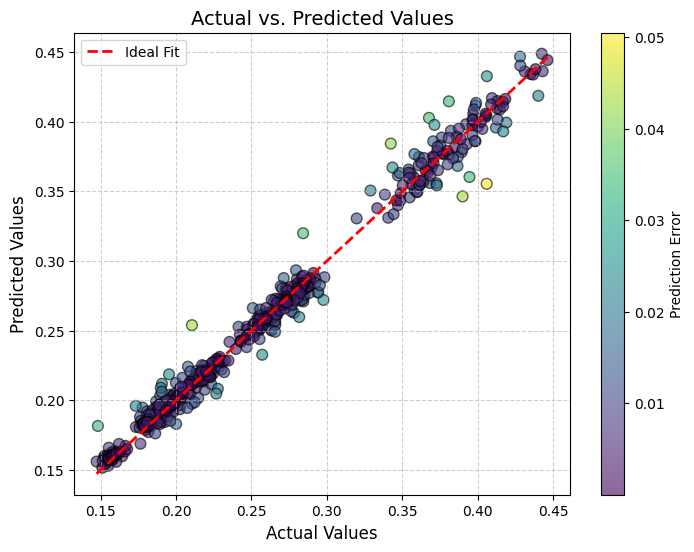

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define a color gradient based on error magnitude
errors = np.abs(y_test - y_pred)

plt.figure(figsize=(8, 6))  # Set figure size
sc = plt.scatter(y_test, y_pred, c=errors, cmap='viridis', alpha=0.6, edgecolors='k', s=60)

# Plot the ideal diagonal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2, label="Ideal Fit")

# Add color bar
cbar = plt.colorbar(sc)
cbar.set_label("Prediction Error")

# Labels and title
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs. Predicted Values', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


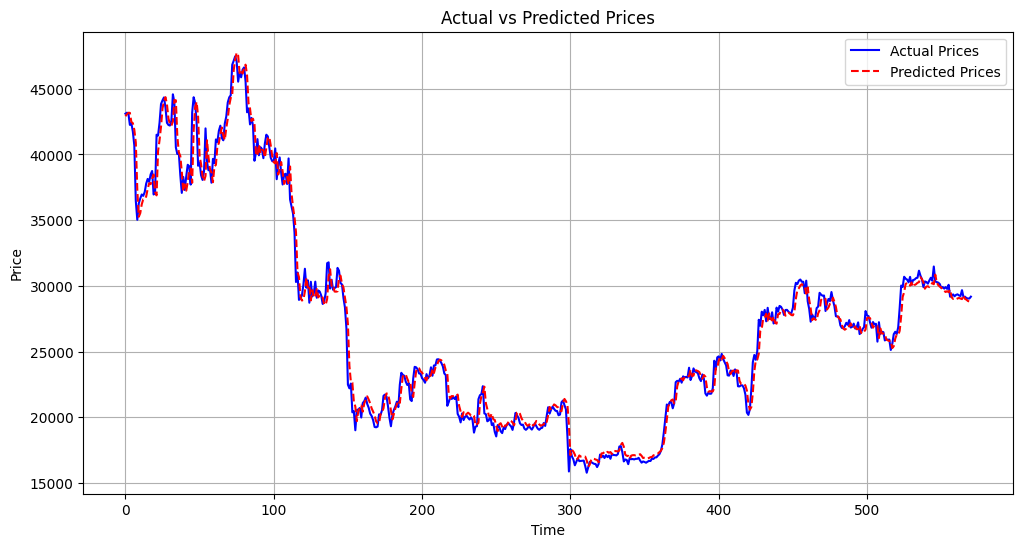

In [ ]:
# Ensure you use the same scaler that was used for fitting
y_test_inv = Scaler.inverse_transform(np.array(y_test).reshape(-1, 1))
y_pred_lstm_inv = Scaler.inverse_transform(np.array(y_pred).reshape(-1, 1))

# Plot Actual vs Predicted Prices for LSTM
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label="Actual Prices", color='blue', linestyle='solid')
plt.plot(y_pred_lstm_inv, label="Predicted Prices", color='red', linestyle='dashed')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid()

plt.show()


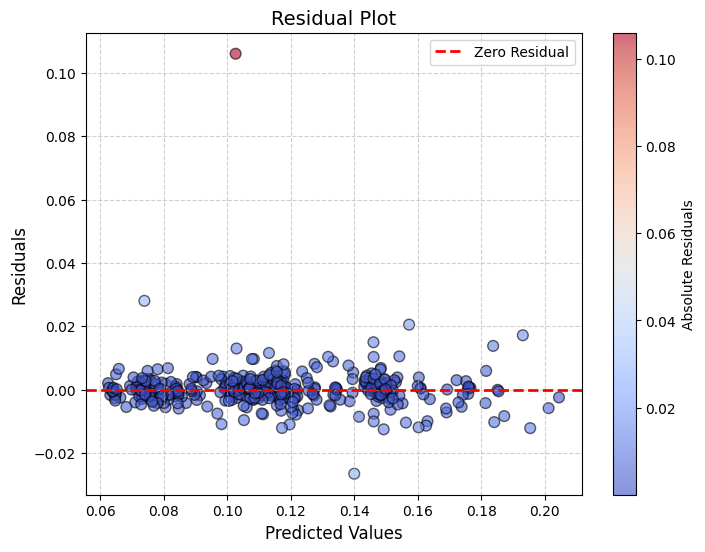

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compute residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))  # Set figure size

# Scatter plot with color gradient
sc = plt.scatter(y_pred, residuals, c=np.abs(residuals), cmap='coolwarm', alpha=0.6, edgecolors='k', s=60)

# Horizontal reference line at zero residual
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label="Zero Residual")

# Color bar to indicate residual magnitude
cbar = plt.colorbar(sc)
cbar.set_label("Absolute Residuals")

# Labels and title
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([39, 1])) that is different to the input size (torch.Size([39])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([79, 1])) that is different to the input size (torch.Size([79])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([119, 1])) that is different to the input size (torch.Size([119])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(inpu

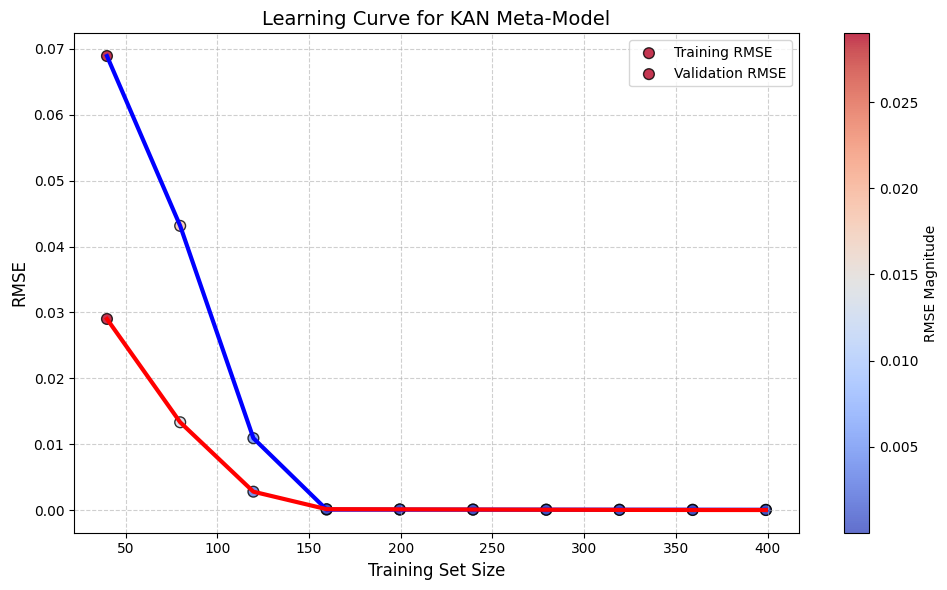

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch

# Convert tensors to NumPy arrays
X_np = X_meta_train_tensor.numpy()
y_np = y_meta_train_tensor.numpy()

train_sizes = np.linspace(0.1, 1.0, 10)
train_errors = []
val_errors = []

for frac in train_sizes:
    size = int(frac * len(X_np))
    X_frac = torch.tensor(X_np[:size], dtype=torch.float32)
    y_frac = torch.tensor(y_np[:size], dtype=torch.float32)

    model = bestt_model  # Your best model instance
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    model.train()
    for epoch in range(50):
        optimizer.zero_grad()
        output = model(X_frac).squeeze()
        loss = criterion(output, y_frac)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_pred = model(X_frac).squeeze().numpy()
        val_pred = model(X_meta_test_tensor).squeeze().numpy()

    train_rmse = mean_squared_error(y_frac.numpy(), train_pred)
    val_rmse = mean_squared_error(y_pred, val_pred)

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

train_errors.sort(reverse=True)
val_errors.sort(reverse=True)

# Plot with enhanced visuals
plt.figure(figsize=(10, 6))

# Gradient-like effect using scatter points
sc1 = plt.scatter(train_sizes * len(X_np), train_errors, c=train_errors, cmap='coolwarm', label='Training RMSE', s=60, edgecolors='k', alpha=0.8)
sc2 = plt.scatter(train_sizes * len(X_np), val_errors, c=val_errors, cmap='coolwarm', label='Validation RMSE', s=60, edgecolors='k', alpha=0.8)

# Lines connecting points
plt.plot(train_sizes * len(X_np), train_errors, color='blue', linewidth=3, alpha=1)
plt.plot(train_sizes * len(X_np), val_errors, color='red', linewidth=3, alpha=1)

# Colorbar to show error scale
cbar = plt.colorbar(sc2)
cbar.set_label("RMSE Magnitude")

# Axes, title, and grid styling
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Learning Curve for KAN Meta-Model', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


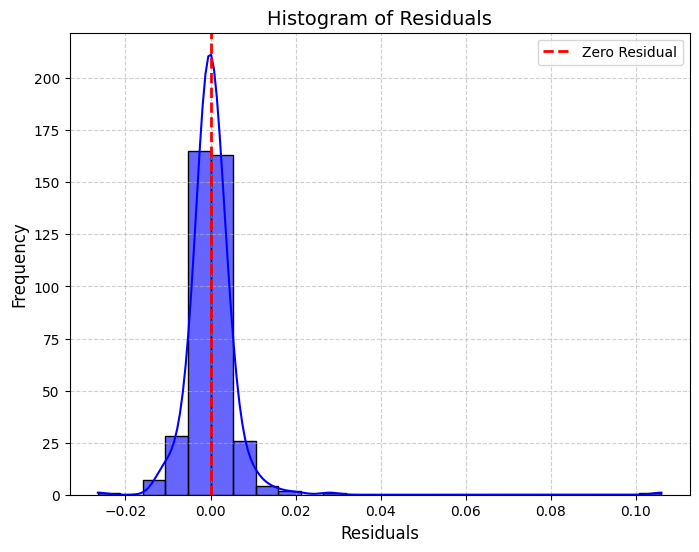

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set figure size
plt.figure(figsize=(8, 6))

# Plot histogram with KDE (density=True makes it comparable)
sns.histplot(residuals, bins=25, kde=True, color='blue', alpha=0.6, edgecolor='black')

# Add vertical line at zero residual
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')

# Labels and title
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Residuals', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
def monte_carlo_next_day(prices, num_simulations=10000):
    import numpy as np
    log_returns = np.log(np.array(prices[1:]) / np.array(prices[:-1]))
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)

    simulated_returns = np.random.normal(mu, sigma, num_simulations)
    predicted_prices = prices[-1] * np.exp(simulated_returns)

    expected_price = np.mean(predicted_prices)

    return expected_price

In [ ]:
def monte_carlo_next_day_gbm(prices, num_simulations=10000):
    import numpy as np

    # Calculate log returns from input prices
    log_returns = np.log(np.array(prices[1:]) / np.array(prices[:-1]))
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)

    # Time step (1 day, assuming 252 trading days per year)
    dt = 1 / 365

    # Generate simulations using GBM formula
    Z = np.random.normal(0, 1, num_simulations)
    drift = (mu - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    simulated_returns = drift + diffusion

    # Predict prices
    predicted_prices = prices[-1] * np.exp(simulated_returns)
    expected_price = np.mean(predicted_prices)

    return expected_price

def monte_carlo_next_day_cir(prices, num_simulations=10000):
    import numpy as np

    # Calculate log returns from input prices
    log_returns = np.log(np.array(prices[1:]) / np.array(prices[:-1]))
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)

    # Time step (1 day, assuming 252 trading days per year)
    dt = 1 / 365

    # Generate simulations using GBM formula
    Z = np.random.normal(0, 1, num_simulations)
    simulated_returns = 1*(mu - max([0,prices[-1]]))*dt + Z*sigma*(max([0,prices[-1]])*dt)*0.5

    # Predict prices
    predicted_prices = prices[-1]*np.exp(simulated_returns)
    expected_price = np.mean(predicted_prices)

    return expected_price

def monte_carlo_next_day_nor(prices, num_simulations=10000):
    import numpy as np

    # Calculate log returns from input prices
    log_returns = np.log(np.array(prices[1:]) / np.array(prices[:-1]))
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)

    # Time step (1 day, assuming 252 trading days per year)
    dt = 1 / 365

    # Generate simulations using GBM formula
    Z = np.random.normal(mu, sigma, num_simulations)
    simulated_returns = Z

    # Predict prices
    predicted_prices = prices[-1]*np.exp(simulated_returns)
    expected_price = np.mean(predicted_prices)

    return expected_price

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
BTC = yf.Ticker('XRP-USD')
data = BTC.history(start='2010-03-01',end='2025-03-01')
Scaler = MinMaxScaler()
data[['Close']] = Scaler.fit_transform(data[['Close']])
train_df, test_df = train_test_split(data, test_size=0.3, random_state=42, shuffle = False)
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=42, shuffle = False)

y_train = train_df['Close']

y_test = test_df['Close']

y_val = val_df['Close']
gbmarr = []
cirarr = []
norarr = []
for i in range(len(y_test)-4):
  prices = y_test[i:i+4]
  gbmarr.append(monte_carlo_next_day_gbm(prices))
  cirarr.append(monte_carlo_next_day_cir(prices))
  norarr.append(monte_carlo_next_day_nor(prices))

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

print(r2_score(gbmarr, y_test[4:]))
print(mean_squared_error(gbmarr, y_test[4:]))
print(mean_absolute_error(gbmarr, y_test[4:]))
print(root_mean_squared_error(gbmarr, y_test[4:]))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(r2_score(cirarr, y_test[4:]))
print(mean_squared_error(cirarr, y_test[4:]))
print(mean_absolute_error(cirarr, y_test[4:]))
print(root_mean_squared_error(cirarr, y_test[4:]))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(r2_score(norarr, y_test[4:]))
print(mean_squared_error(norarr, y_test[4:]))
print(mean_absolute_error(norarr, y_test[4:]))
print(root_mean_squared_error(norarr, y_test[4:]))

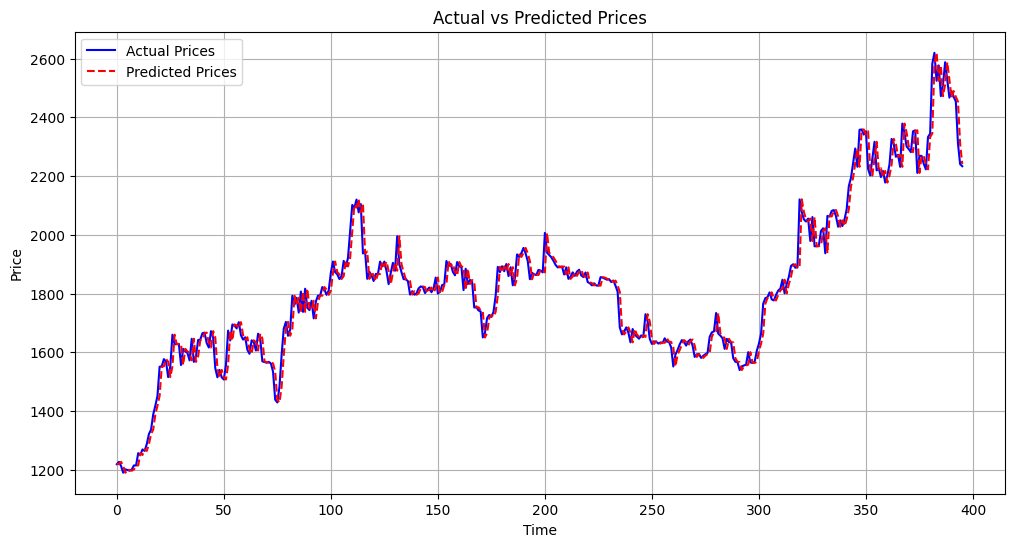

In [ ]:
# Ensure you use the same scaler that was used for fitting
y_test_inv = Scaler.inverse_transform(np.array(y_test[4:]).reshape(-1, 1))
y_pred_gbm_inv = Scaler.inverse_transform(np.array(gbmarr).reshape(-1, 1))
y_pred_cir_inv = Scaler.inverse_transform(np.array(cirarr).reshape(-1, 1))
y_pred_nor_inv = Scaler.inverse_transform(np.array(norarr).reshape(-1, 1))

# Plot Actual vs Predicted Prices for Monte Carlo
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label="Actual Prices", color='blue', linestyle='solid')
plt.plot(y_pred_gbm_inv, label="Predicted Prices", color='red', linestyle='dashed')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid()

plt.show()


In [ ]:
for i in range(len(y_test_inv)):
  print(y_test_inv,y_pred_gbm_inv)

Streaming output truncated to the last 5000 lines.
 [1817.54979928]
 [1824.15041684]
 [1821.87302201]
 [1801.71295142]
 [1812.58292014]
 [1820.47225294]
 [1804.53755245]
 [1817.53875246]
 [1854.41578289]
 [1800.10747739]
 [1805.93140764]
 [1828.67895887]
 [1831.14726632]
 [1911.00744076]
 [1893.16883096]
 [1901.05190166]
 [1874.10804919]
 [1862.15908421]
 [1907.2754213 ]
 [1892.43591612]
 [1890.53450111]
 [1811.73917916]
 [1884.44976913]
 [1832.34394406]
 [1846.32008192]
 [1840.16354038]
 [1752.35179785]
 [1753.3535401 ]
 [1742.4511627 ]
 [1739.02788621]
 [1650.43441484]
 [1665.4834058 ]
 [1716.65945256]
 [1727.28624008]
 [1720.63818094]
 [1737.67919446]
 [1792.1818836 ]
 [1891.19603058]
 [1873.06927449]
 [1892.94574829]
 [1876.04345625]
 [1900.54400165]
 [1859.39267635]
 [1889.73436509]
 [1827.90302162]
 [1852.21636362]
 [1933.20896457]
 [1924.6195103 ]
 [1937.54052498]
 [1955.4104644 ]
 [1936.63074859]
 [1910.56632367]
 [1848.5480969 ]
 [1870.55119468]
 [1865.49302464]
 [1863.0262481

In [ ]:
monte_carlo_next_day([85121,82485.5,83160,83861.5])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def gbm_monte_carlo_next_day(four_day_prices, num_simulations=1000, dt=1/365):
    """
    Predict next day close price using GBM Monte Carlo based on last 4 days' prices.
    """
    log_returns = np.log(four_day_prices[1:] / four_day_prices[:-1])
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)

    Z = np.random.normal(0, 1, num_simulations)
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    simulated_returns = drift + diffusion
    predicted_prices = four_day_prices[-1] * np.exp(simulated_returns)
    expected_price = np.mean(predicted_prices)

    return expected_price, predicted_prices

def run_rolling_predictions(prices, num_simulations=1000):
    """
    Run GBM Monte Carlo predictions over full dataset using a 4-day rolling window.
    """
    predictions = []
    actuals = []

    for i in range(4, len(prices)-1):
        four_day_window = prices[i-4:i]
        next_actual = prices[i]  # Actual price at day i

        predicted_price, _ = gbm_monte_carlo_next_day(four_day_window, num_simulations)
        predictions.append(predicted_price)
        actuals.append(next_actual)

    return np.array(predictions), np.array(actuals)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
BTC = yf.Ticker('BTC-USD')
#data = BTC.history(start='2010-03-01',end='2025-03-01')
data = BTC.history(period='15y')
train_df, test_df = train_test_split(data, test_size=0.15, random_state=42, shuffle = False)

y_train = train_df['Close']

y_test = test_df['Close']

pred, act = run_rolling_predictions(y_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(r2_score(pred, act))
print(mean_squared_error(pred, act))
print(mean_absolute_error(pred, act))

In [ ]:
print(pred[-2],act[-2])

In [ ]:
def plot_univariate_functions(kan_model, X_data, feature_names=None):
    num_features = X_data.size(1)
    if feature_names is None:
        feature_names = [f'Feature {i+1}' for i in range(num_features)]

    plt.figure(figsize=(12, 8))

    for i in range(num_features):
        # Set up the subplot before plotting
        plt.subplot((num_features + 1) // 2, 2, i + 1)

        # Get the specific univariate function for the feature
        univariate_func = kan_model.univariate_funcs[i]

        # Generate a range of input values
        xi_min = X_data[:, i].min().item()
        xi_max = X_data[:, i].max().item()
        xi_range = torch.linspace(xi_min, xi_max, 100).unsqueeze(1)

        # Pass through the univariate function
        with torch.no_grad():
            yi_all = univariate_func(xi_range)
            for j in range(yi_all.size(1)):  # Plot each output line separately
                yi = yi_all[:, j].squeeze().numpy()
                plt.plot(xi_range.numpy(), yi, label=f'Intermediate Output {j+1}')

        # Add titles and labels
        plt.title(f'Univariate Function for {feature_names[i]}')
        plt.xlabel('Input Value')
        plt.ylabel('Output Value')

        # Add a legend only if labels are present
        if yi_all.size(1) > 0:
            plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_univariate_functions(bestt_model, X_train)